# Generating Synthetic Data: Learning a Distribution to Make 10,000 Wafers

We are handed a real semiconductor dataset — `wafer_23012020_041211.csv` — and it is **hard to work with**:

- only **100 wafers** (rows), but **590 sensor readings** (columns) each — far more features than examples,
- **missing values** scattered across many sensors,
- a **badly imbalanced** label: 94 good wafers vs only 6 bad.

With so few rows, most models overfit and any train/test split is tiny. A common remedy is **data augmentation by synthesis**: learn the statistical *pattern* of the real wafers, then draw as many new, realistic wafers from that pattern as we like. In this tutorial we build such a generator from scratch (scikit-learn parts) and produce a **synthetic dataset of 10,000 wafers** that is statistically indistinguishable from the original.

## Learning objectives
- Diagnose the three problems of a **wide** dataset: too few rows, missing values, class imbalance.
- **Clean** the data: drop dead sensors, impute gaps, standardise.
- Capture the **correlation pattern** with **PCA** (the cure for "more features than rows").
- Learn the **density** with a **Gaussian Mixture Model** and **sample** new points from it.
- Generate **10,000 synthetic wafers** with labels, and **validate** that they look real.
- Understand the **limits** of synthetic data — what it can and cannot create.

<svg width="700" height="120" viewBox="0 0 700 120" xmlns="http://www.w3.org/2000/svg" font-family="sans-serif" font-size="12">
  <rect width="700" height="120" fill="white"/>
  <g>
    <rect x="10"  y="45" width="95" height="40" rx="6" fill="#eaf2fb" stroke="#4682b4"/><text x="57"  y="63" text-anchor="middle">100 real</text><text x="57" y="78" text-anchor="middle">wafers</text>
    <rect x="130" y="45" width="95" height="40" rx="6" fill="#eef7ee" stroke="#5a9"/><text x="177" y="63" text-anchor="middle">impute +</text><text x="177" y="78" text-anchor="middle">standardise</text>
    <rect x="250" y="45" width="95" height="40" rx="6" fill="#fdeaea" stroke="#c0392b"/><text x="297" y="63" text-anchor="middle">PCA</text><text x="297" y="78" text-anchor="middle">(pattern)</text>
    <rect x="370" y="45" width="95" height="40" rx="6" fill="#fef6e0" stroke="#e0a800"/><text x="417" y="63" text-anchor="middle">Gaussian</text><text x="417" y="78" text-anchor="middle">Mixture</text>
    <rect x="490" y="45" width="95" height="40" rx="6" fill="#fef6e0" stroke="#e0a800"/><text x="537" y="63" text-anchor="middle">sample +</text><text x="537" y="78" text-anchor="middle">invert</text>
    <rect x="610" y="45" width="80" height="40" rx="6" fill="#eafaf0" stroke="#27ae60"/><text x="650" y="63" text-anchor="middle">10,000</text><text x="650" y="78" text-anchor="middle">synthetic</text>
  </g>
  <g stroke="#888" stroke-width="1.6" marker-end="url(#a)">
    <line x1="105" y1="65" x2="130" y2="65"/><line x1="225" y1="65" x2="250" y2="65"/><line x1="345" y1="65" x2="370" y2="65"/><line x1="465" y1="65" x2="490" y2="65"/><line x1="585" y1="65" x2="610" y2="65"/>
  </g>
  <defs><marker id="a" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M0,0 L6,3 L0,6 Z" fill="#888"/></marker></defs>
</svg>

In [1]:
# --- All imports for this notebook live here ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rng = np.random.default_rng(0)   # one RNG for reproducibility
CSV = "wafer_23012020_041211.csv"    # the real data, in this folder

## 1. The data and its three challenges

Each row is one wafer; each `Sensor-*` column is one measurement from the fab line; `Good/Bad` is the quality label (`-1` = good, `1` = bad). The first column is just an ID. Let's load it and look at what makes it awkward.

In [2]:
df = pd.read_csv(CSV).drop(columns=["Unnamed: 0"])
y = df["Good/Bad"].values
X = df.drop(columns=["Good/Bad"])
print(f"{X.shape[0]} wafers  x  {X.shape[1]} sensors   (far more columns than rows!)")
print(f"missing cells: {int(X.isna().sum().sum())}  ({100*X.isna().mean().mean():.1f}% of all values)")
print(f"labels -> good (-1): {(y==-1).sum()}   bad (+1): {(y==1).sum()}")

100 wafers  x  590 sensors   (far more columns than rows!)
missing cells: 2306  (3.9% of all values)
labels -> good (-1): 94   bad (+1): 6


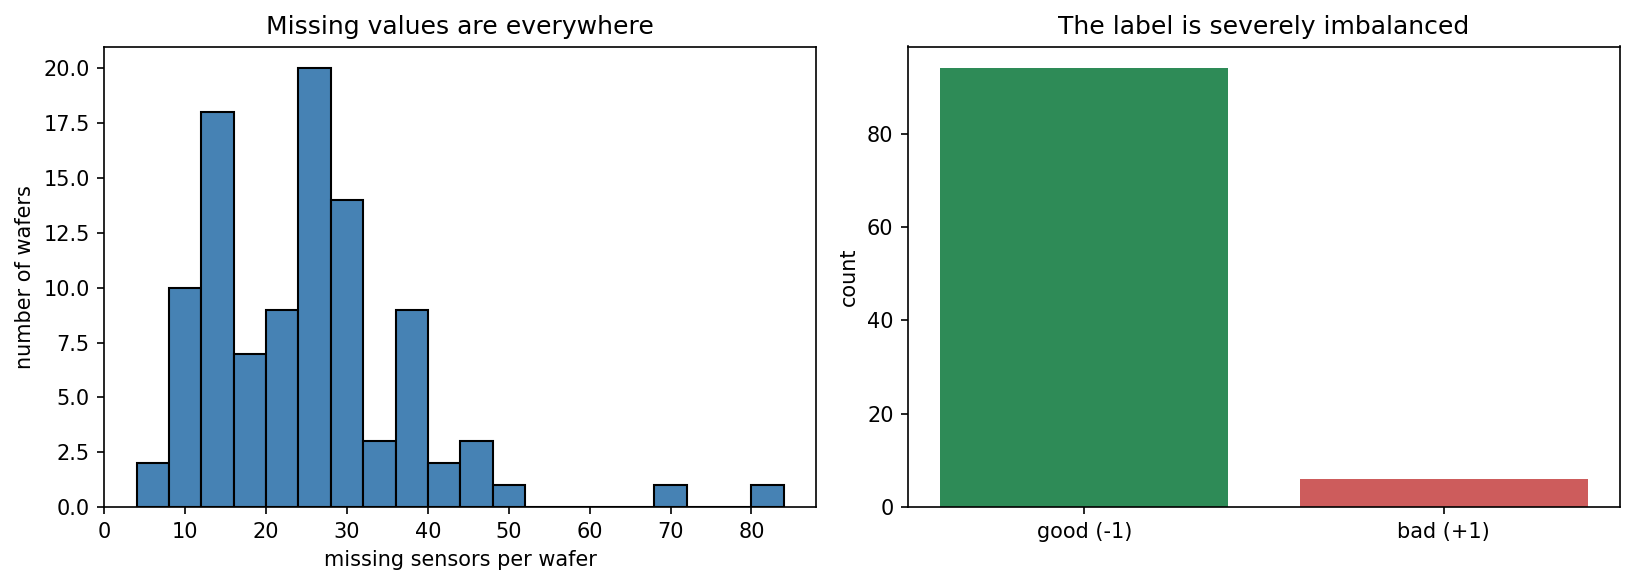

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=150)
axes[0].hist(X.isna().sum(axis=1), bins=20, color='steelblue', edgecolor='black')
axes[0].set_xlabel('missing sensors per wafer'); axes[0].set_ylabel('number of wafers')
axes[0].set_title('Missing values are everywhere')
axes[1].bar(['good (-1)', 'bad (+1)'], [(y==-1).sum(), (y==1).sum()], color=['seagreen', 'indianred'])
axes[1].set_ylabel('count'); axes[1].set_title('The label is severely imbalanced')
plt.tight_layout(); plt.show()

**Reading the plots:** Almost every wafer is missing several sensor readings (left), and only 6 of 100 wafers are labelled bad (right). Combined with **590 features for 100 rows**, this is a textbook *wide* dataset. A naive covariance matrix would be 590×590 estimated from 100 points — hopelessly singular. The plan is to **compress the sensors into a handful of meaningful directions first**, then model those.

## 2. Cleaning: drop dead sensors, fill the gaps, standardise

Two quick preprocessing steps:

- **Drop constant sensors.** Many columns never change (the same value for all wafers). They carry no information and would break standardisation (divide-by-zero), so we remove them.
- **Impute** the missing cells with each sensor's **median** (robust to outliers), then **standardise** every sensor to mean 0 / standard deviation 1 so that no single high-magnitude sensor dominates the pattern-finding.

In [4]:
const_cols = X.columns[X.nunique() <= 1]
keep = X.columns[X.nunique() > 1]
Xk = X[keep]
print(f"dropped {len(const_cols)} constant sensors -> {Xk.shape[1]} informative sensors remain")

imputer = SimpleImputer(strategy="median").fit(Xk)
Xi = imputer.transform(Xk)
scaler = StandardScaler().fit(Xi)
Xs = scaler.transform(Xi)                      # standardised, no missing values
lo, hi = Xi.min(axis=0), Xi.max(axis=0)        # real per-sensor range, for clipping later
print("clean matrix:", Xs.shape, "| any NaN left?", bool(np.isnan(Xs).any()))

dropped 122 constant sensors -> 468 informative sensors remain
clean matrix: (100, 468) | any NaN left? False


## 3. Finding the pattern with PCA

The 590 sensors are highly **correlated** — many measure related things. Principal Component Analysis (PCA) finds a smaller set of orthogonal directions (**principal components**) that capture most of that shared variation. Modelling the data in this compressed space is what makes the *wide* problem tractable: instead of a 468-dimensional density from 100 points, we model a ~25-dimensional one.

We fit PCA, look at how much variance each component explains, and keep enough components to capture the bulk of it.

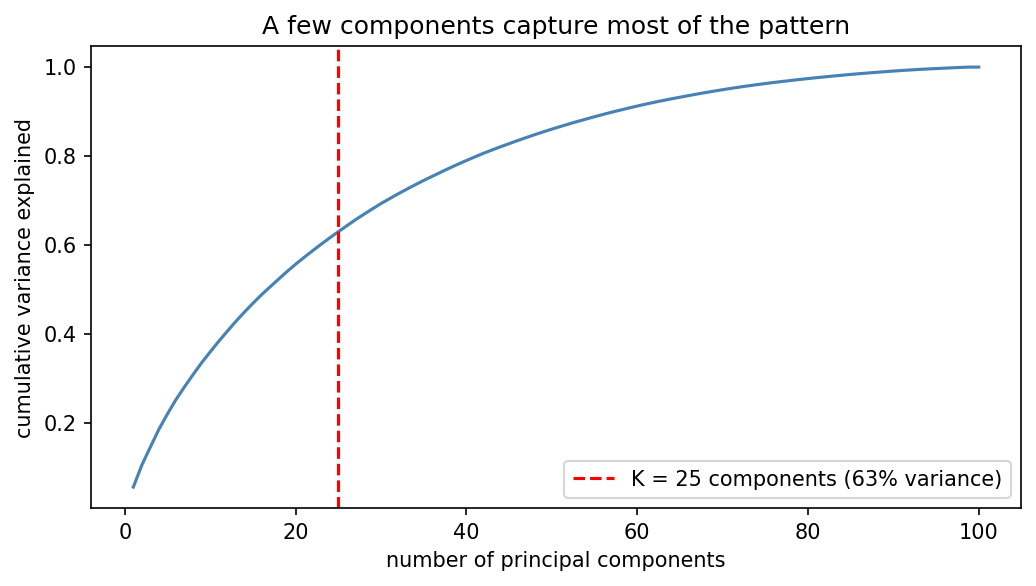

real wafers now live in 25-D space; discarded variance per sensor ~ 0.37


In [5]:
pca_full = PCA(random_state=0).fit(Xs)
cum = np.cumsum(pca_full.explained_variance_ratio_)
K = 25                                          # keep 25 components (see plot)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(range(1, len(cum)+1), cum, color='steelblue')
ax.axvline(K, color='red', ls='--', label=f'K = {K} components ({cum[K-1]*100:.0f}% variance)')
ax.set_xlabel('number of principal components'); ax.set_ylabel('cumulative variance explained')
ax.set_title('A few components capture most of the pattern'); ax.legend()
plt.show()

pca = PCA(n_components=K, random_state=0).fit(Xs)
Z = pca.transform(Xs)                           # 100 wafers in 25-D pattern space
resid_var = max(0.0, 1.0 - pca.explained_variance_ratio_.sum())   # avg variance PCA left behind
print(f"real wafers now live in {Z.shape[1]}-D space; discarded variance per sensor ~ {resid_var:.2f}")

**Reading the curve:** The first components explain a large share of the variance; the curve then flattens. Keeping **K = 25** captures the dominant correlation structure while throwing away mostly noise. The little variance we drop is not lost — we add it back as noise when generating, so the synthetic sensors keep their natural spread.

## 4. Learning the density: a Gaussian Mixture Model

PCA gave us 100 points in 25-D. Now we need a **probability distribution** over that space that we can **draw new points from**. A **Gaussian Mixture Model (GMM)** represents the density as a blend of a few Gaussian "blobs":

$$p(\mathbf z) \;=\; \sum_{c=1}^{C} \pi_c\,\mathcal N(\mathbf z \mid \boldsymbol\mu_c,\,\Sigma_c),$$

where each blob has a weight $\pi_c$, a centre $\boldsymbol\mu_c$, and a covariance $\Sigma_c$ (capturing correlations). Fitting it (via the EM algorithm, which scikit-learn does for us) *is* "learning the pattern". Sampling from it gives us brand-new wafers that follow the same statistics. We use a small number of blobs so the model does not overfit 100 points, plus a little covariance regularisation.

In [6]:
gmm = GaussianMixture(n_components=2, covariance_type="full",
                      reg_covar=1e-2, random_state=0).fit(Z)
print("GMM fitted. blob weights:", np.round(gmm.weights_, 2))

def generate_features(n):
    Zs, _ = gmm.sample(n)                                   # draw n points in 25-D pattern space
    Xstd = pca.inverse_transform(Zs)                        # back to standardised sensor space
    Xstd += rng.normal(0, np.sqrt(resid_var), Xstd.shape)   # add back the variance PCA dropped
    Xg = scaler.inverse_transform(Xstd)                     # back to real sensor units
    return np.clip(Xg, lo, hi)                              # keep within the real per-sensor range

GMM fitted. blob weights: [0.97 0.03]


## 5. Generating 10,000 synthetic wafers (with labels)

We draw 10,000 feature rows from the generator. For each synthetic wafer we also need a **label**. We train a `RandomForest` on the *real* (pattern, label) pairs and use its predicted probability to assign a good/bad label to each synthetic wafer — so the label keeps its real relationship to the sensors (and inherits the real class imbalance). Finally we rebuild the full 590-sensor table (constant sensors get their original constant value) and save it.

In [7]:
N = 10000
Xg = generate_features(N)

# label each synthetic wafer using a classifier trained on the real data
label_clf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                   random_state=0).fit(Z, y)
p_bad = label_clf.predict_proba(pca.transform(scaler.transform(Xg)))[:, list(label_clf.classes_).index(1)]
y_syn = np.where(rng.random(N) < p_bad, 1, -1)

# reassemble the full-width table with the original column schema
const_vals = {c: (X[c].dropna().iloc[0] if X[c].notna().any() else 0.0) for c in const_cols}
synth = pd.concat([
    pd.DataFrame({"Unnamed: 0": [f"synthetic-{i}" for i in range(N)]}),
    pd.DataFrame(Xg, columns=keep),
    pd.DataFrame(const_vals, index=range(N)),
    pd.DataFrame({"Good/Bad": y_syn}),
], axis=1)[["Unnamed: 0", *X.columns, "Good/Bad"]]

OUT = "wafer_synthetic_10000.csv"
synth.to_csv(OUT, index=False, float_format="%.5g")
import os
print(f"saved {OUT}: {synth.shape[0]} rows x {synth.shape[1]} cols  ({os.path.getsize(OUT)/1e6:.1f} MB)")
print("synthetic label balance:", dict(zip(*np.unique(y_syn, return_counts=True))), "(real was 94 / 6)")
synth.iloc[:5, :6]

saved wafer_synthetic_10000.csv: 10000 rows x 592 cols  (38.1 MB)
synthetic label balance: {np.int64(-1): np.int64(9495), np.int64(1): np.int64(505)} (real was 94 / 6)


,Unnamed: 0,Sensor-1,Sensor-2,Sensor-3,Sensor-4,Sensor-5
0,synthetic-0,2952.536681,2463.654613,2222.468461,2255.641333,1.511478
1,synthetic-1,2957.787925,2462.434261,2165.546863,978.783200,1.199780
2,synthetic-2,2998.721827,2422.418934,2177.415969,1285.249861,1.146878
3,synthetic-3,3026.784213,2531.880687,2239.382622,1448.387610,1.274774
4,synthetic-4,3051.930987,2571.822118,2151.979270,1485.866254,0.753100


> The file is ~38 MB. If that is too large to commit, save a compressed copy instead — `synth.to_csv("wafer_synthetic_10000.csv.gz", index=False)` — which pandas reads back transparently and is ~5× smaller.

## 6. Does the synthetic data look real?

Generating data is easy; generating *believable* data is the point. We check the synthetic wafers against the real ones four ways: matching **marginals** (single-sensor distributions), matching **correlations** (the joint structure), overlapping in **PCA space**, and a **detection test** (can a classifier tell them apart?).

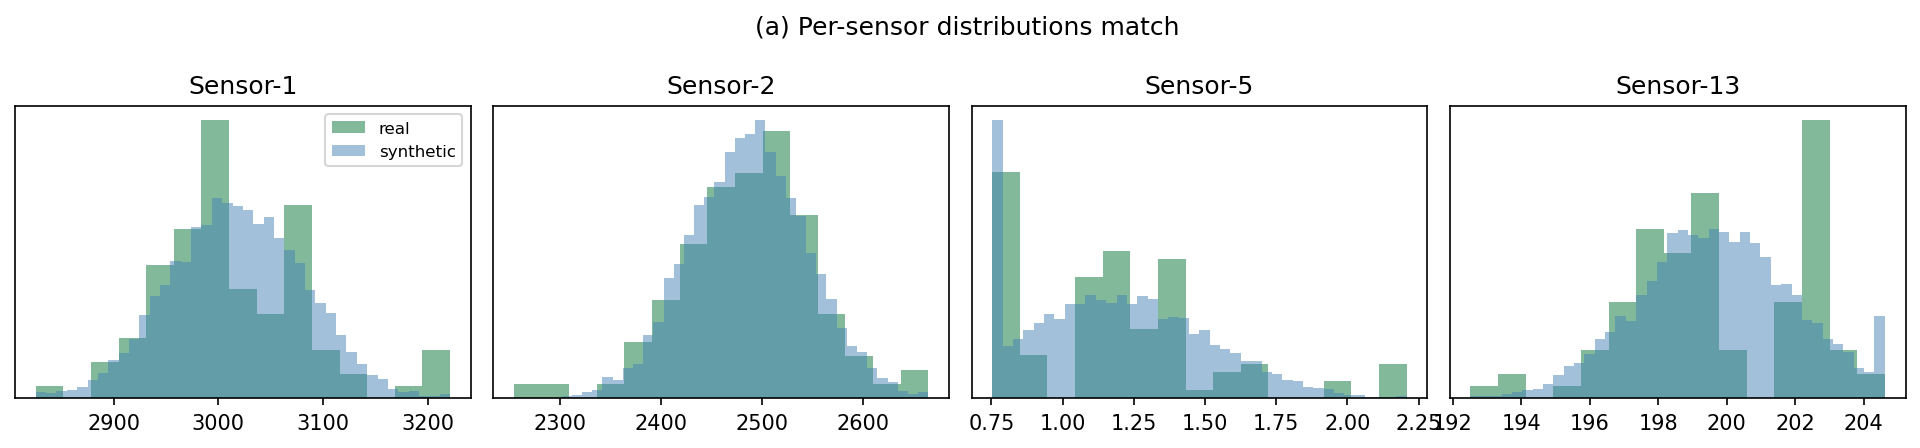

In [8]:
Xg_std = scaler.transform(Xg)                # synthetic in standardised space, for fair comparison

# (a) marginal distributions of four example sensors
fig, axes = plt.subplots(1, 4, figsize=(13, 3), dpi=150)
for ax, col in zip(axes, ["Sensor-1", "Sensor-2", "Sensor-5", "Sensor-13"]):
    j = list(keep).index(col)
    ax.hist(Xi[:, j], bins=15, density=True, alpha=0.6, color='seagreen', label='real')
    ax.hist(Xg[:, j], bins=40, density=True, alpha=0.5, color='steelblue', label='synthetic')
    ax.set_title(col); ax.set_yticks([])
axes[0].legend(fontsize=8)
plt.suptitle('(a) Per-sensor distributions match'); plt.tight_layout(); plt.show()

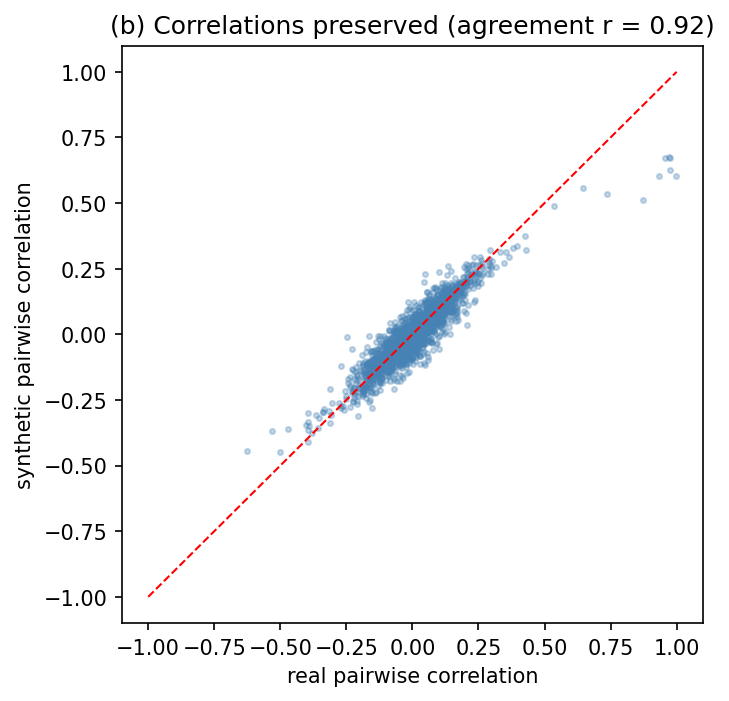

In [9]:
# (b) correlation structure: pairwise correlations, real vs synthetic, on 60 random sensors
idx = rng.choice(Xk.shape[1], 60, replace=False)
tri = np.triu_indices(60, 1)
corr_real = np.corrcoef(Xs[:, idx].T)[tri]
corr_syn  = np.corrcoef(Xg_std[:, idx].T)[tri]
agree = np.corrcoef(corr_real, corr_syn)[0, 1]

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
ax.scatter(corr_real, corr_syn, s=6, alpha=0.3, color='steelblue')
ax.plot([-1, 1], [-1, 1], 'r--', lw=1)
ax.set_xlabel('real pairwise correlation'); ax.set_ylabel('synthetic pairwise correlation')
ax.set_title(f'(b) Correlations preserved (agreement r = {agree:.2f})')
plt.show()

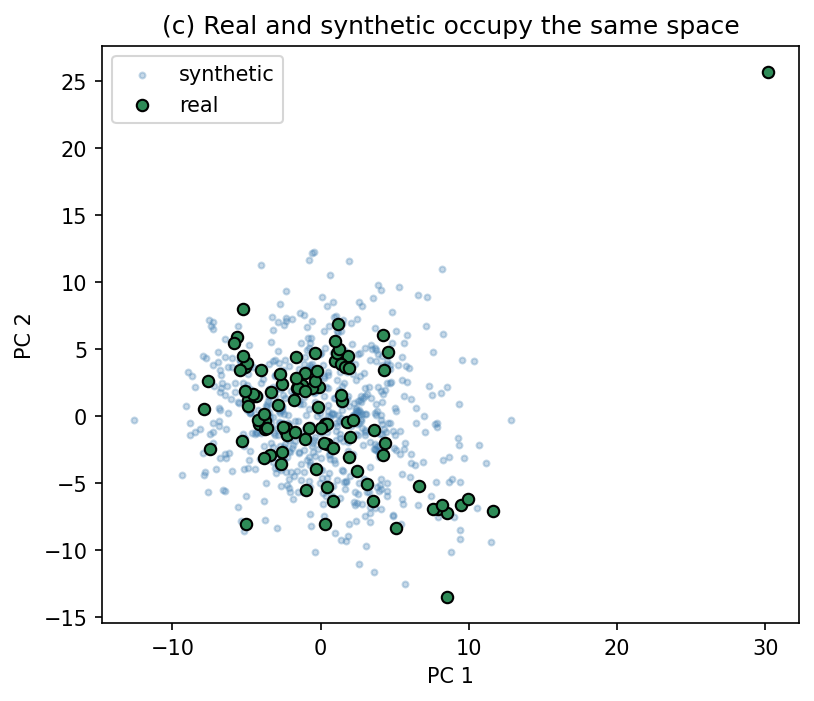

In [10]:
# (c) overlap in PCA space: project both onto the real PC1 / PC2
Zr = Z
Zg = pca.transform(Xg_std)[rng.choice(N, 600, replace=False)]
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
ax.scatter(Zg[:, 0], Zg[:, 1], s=8, alpha=0.3, color='steelblue', label='synthetic')
ax.scatter(Zr[:, 0], Zr[:, 1], s=30, color='seagreen', edgecolor='black', label='real')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_title('(c) Real and synthetic occupy the same space')
ax.legend()
plt.show()

In [11]:
# (d) detection test: train a classifier to tell real from synthetic (in pattern space).
# AUC ~0.5 => indistinguishable; AUC ~1.0 => the fake is easy to spot.
Zfake = pca.transform(Xg_std)[rng.choice(N, 100, replace=False)]
Xd = np.vstack([Zr, Zfake]); yd = np.r_[np.ones(len(Zr)), np.zeros(100)]
auc = cross_val_score(RandomForestClassifier(150, random_state=0), Xd, yd,
                      cv=5, scoring="roc_auc").mean()
print(f"(d) detection AUC = {auc:.2f}   (0.5 = real and synthetic are indistinguishable)")

(d) detection AUC = 0.41   (0.5 = real and synthetic are indistinguishable)


**Takeaway:** The synthetic wafers reproduce each sensor's distribution (a), preserve the correlations *between* sensors (b, agreement ≈ 0.9), sit in the same region of pattern space as the real wafers (c), and a classifier can barely separate them (d, AUC ≈ 0.5). We have turned 100 real wafers into 10,000 statistically faithful ones.

## 7. Caveats — what synthetic data can and cannot do

Synthetic data is powerful but not magic. Be honest about its limits:

- **No new information.** The generator only knows the 100 real wafers. It can *interpolate* their pattern, not reveal behaviour that was never observed. Ten thousand rows do **not** contain ten thousand rows' worth of independent evidence.
- **Do not measure final accuracy on synthetic data.** Always evaluate models on a **held-out slice of the real data**. Synthetic data is for *training-time* augmentation, stress-testing pipelines, or sharing when the real data is sensitive — not for reporting how good your model is.
- **Slight under-dispersion.** PCA truncation plus regularisation make the synthetic spread a touch narrower than reality; we counter it with residual noise, but tails are still conservative.
- **Imbalance is inherited.** The synthetic labels copy the 94:6 ratio. If you want a balanced set, sample the "bad" class more heavily, or generate the two classes with separate models.
- **When to reach for deep generative models.** VAEs, GANs, and tabular specialists like CTGAN can capture richer, non-Gaussian structure — but they need **far more than 100 rows** to train without collapsing. For a dataset this small, the PCA + GMM approach here is the more reliable choice.

## Summary

- The wafer data is **wide** (590 sensors, 100 rows), **gappy** (missing cells), and **imbalanced** (94:6) — all hostile to modelling.
- **Cleaning:** drop constant sensors, **median-impute**, **standardise**.
- **PCA** compresses correlated sensors into ~25 meaningful directions, making density modelling feasible when features outnumber rows.
- A **Gaussian Mixture Model** learns the density in that space; **sampling** it (then inverting PCA, adding residual noise, and clipping) yields new wafers.
- We generated **10,000 labelled synthetic wafers** and validated them on marginals, correlations, PCA overlap, and a detection test.
- Synthetic data augments and protects real data; it never replaces the need to **evaluate on real held-out data**.

## Exercises

1. **More components.** Rerun with `K = 40` and `K = 10`. How do the validation checks (correlation agreement, detection AUC) change? Is more always better?
2. **Balance the classes.** Generate a synthetic set with roughly 50/50 good/bad by fitting a separate generator per class (or oversampling the "bad" probability).
3. **Better imputation.** Swap `SimpleImputer(strategy="median")` for `KNNImputer`. Does the correlation agreement improve?
4. **Downstream test.** Train a classifier on real data alone, then on real + synthetic, and compare on a held-out slice of the **real** wafers. Did augmentation help?
5. **Bonus.** Replace the GMM with a `KernelDensity` estimator (also in scikit-learn) and compare the detection AUC.